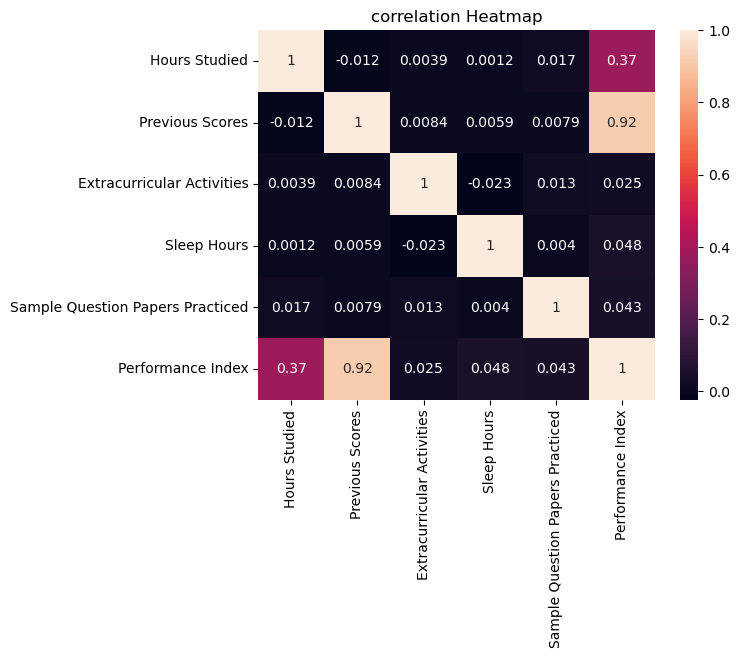

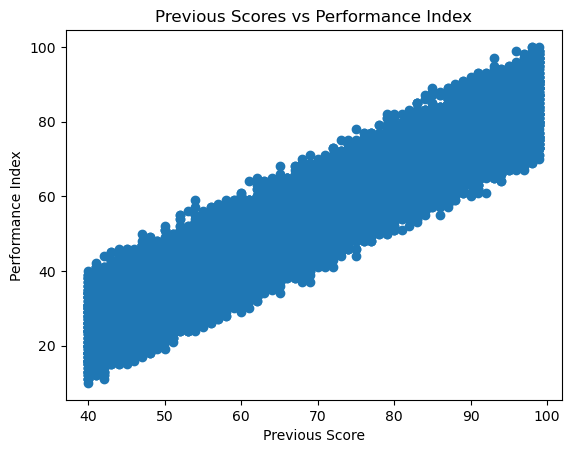

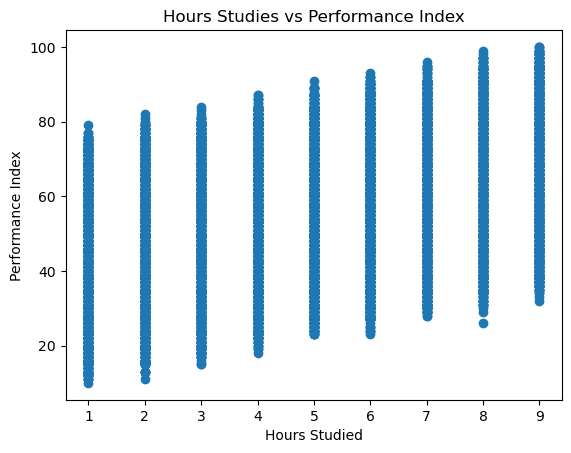

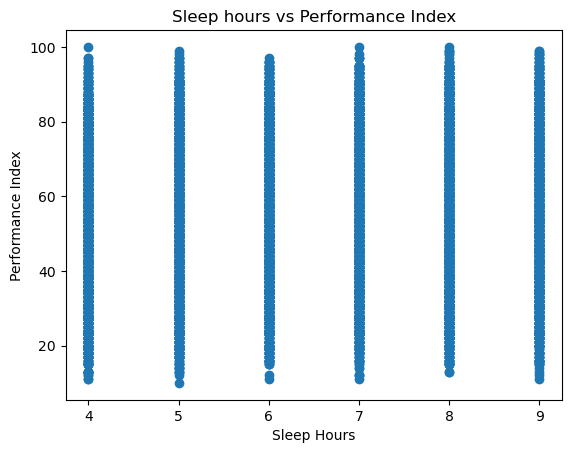

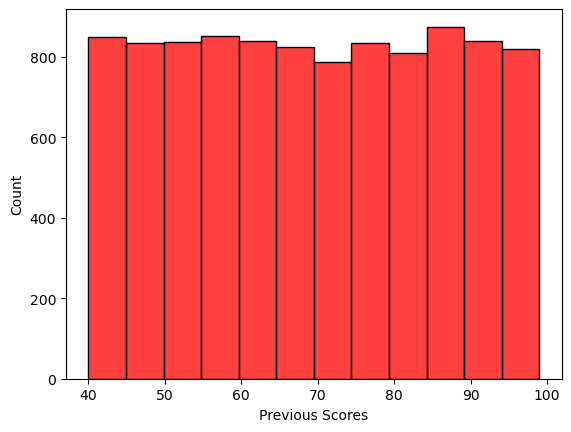

<Figure size 10000x500 with 0 Axes>

(8000, 5)
(2000, 5)
x7 shape is (2000, 5)
train shape is (8000, 4)
[[82.  0.  6.  0. 71.]
 [47.  0.  4.  2. 39.]
 [90.  1.  4.  1. 84.]
 ...
 [70.  1.  5.  3. 58.]
 [77.  1.  9.  0. 51.]
 [73.  0.  7.  6. 56.]]
(8000,)
(8000, 1)
(2000, 5)
(8000, 5)
[[ 0.72236726 -0.9858501  -0.30965511 -1.60010041  0.8174762 ]
 [-1.29807898 -0.9858501  -1.49013684 -0.90275597 -0.84609482]
 [ 1.18418354  1.01435299 -1.49013684 -1.25142819  1.49330193]
 ...
 [ 0.02964283  1.01435299 -0.89989598 -0.55408374  0.14165047]
 [ 0.43373208  1.01435299  1.46106748 -1.60010041 -0.22225569]
 [ 0.20282394 -0.9858501   0.28058575  0.49193292  0.03767728]]
(8000, 6)
(8000, 6)
[[5.52752500e+01]
 [6.25922024e-01]
 [1.17486436e-02]
 [3.07531834e-02]
 [2.45770469e-02]
 [1.86077089e+01]]
the function converge at 417 iteration
 it is [[66.18534986]
 [30.36880946]
 [85.41240004]
 ...
 [69.00633482]
 [20.39632369]
 [54.88811333]]
(2000, 1)
(2000, 1)
0.026746082232059213
The root mean square error is 0.013373041116029607
THE 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df=pd.read_csv('Student_performance.csv')
df.head()
df.loc[df['Extracurricular Activities']=='Yes']
df['Extracurricular Activities']=np.where(df['Extracurricular Activities']=='Yes' , 1, 0)
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation,annot=True)
plt.title('correlation Heatmap')
plt.show()
plt.scatter(df['Previous Scores'],df['Performance Index'])
plt.xlabel('Previous Score')
plt.ylabel('Performance Index')
plt.title('Previous Scores vs Performance Index')
plt.show()
plt.scatter(df['Hours Studied'],df['Performance Index'])
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.title('Hours Studies vs Performance Index')
plt.show()
plt.scatter(df['Sleep Hours'],df['Performance Index'])
plt.xlabel('Sleep Hours')
plt.ylabel('Performance Index')
plt.title('Sleep hours vs Performance Index')
plt.show()
sns.histplot(data=df,x='Previous Scores',binwidth=5,color='red')
plt.figure(figsize=(100,5))
plt.show()
df.head()


train=df.sample(frac=0.8)
test=df.drop(train.index)
train=train.drop(df.columns[0],axis=1)
test=test.drop(df.columns[0],axis=1)
print(train.shape)
print(test.shape)
ytest=test['Performance Index'].to_numpy().reshape(2000,1)
x7=test.to_numpy()
test=test.drop(columns=['Performance Index'])

print(f'x7 shape is {x7.shape}')

x1=train.to_numpy()
y=train['Performance Index'].to_numpy()
y1=y.reshape(8000,1)
train=train.drop(columns=['Performance Index'])
print(f'train shape is {train.shape}')

print(x1)
x=train['Extracurricular Activities'].to_numpy()
print(x.shape)
x2=x.reshape(8000,1)
print(x2.shape)
x3=np.ones((x2.shape))
x12=np.ones((2000,1))
x1scaled=(x1-np.mean(x1,axis=0))/(np.std(x1,axis=0))
x7scaled=(x7-np.mean(x7,axis=0))/(np.std(x7,axis=0))
print(x7scaled.shape)
x6=np.hstack((x12,x7scaled))
print(x1scaled.shape)
print(x1scaled)
x4=np.hstack((x3,x1scaled))
print(x4.shape)  
print(x4.shape)
thetha=np.ones((6,1))
i=1
while i<50000:
    i+=1
    oldthetha=thetha
    h=np.dot(x4,thetha)
    pred=np.array(h-y1)
    thetha=thetha-(0.1/10000)*(np.dot(x4.T,pred))
    if np.all(np.abs(oldthetha-thetha))<0.01:
        print(thetha)
        print(f'the function converge at {i} iteration')
        break
#let begin the error analysis
ytrained=np.dot(x6,thetha)
print(f' it is {ytrained}')
print(ytrained.shape)
error=(ytest-ytrained)**2  
print(error.shape)
mse=(np.sum(error)/10000)
print(mse)
rmse=mse**1/2
print(f"The root mean square error is {rmse}")
ymean=np.mean(y1,axis=0)
error_mean=(y1-ymean)**2
rsquared=1-(np.sum(error)/np.sum(error_mean))
print(f"THE R SQUARED VALUE IS {rsquared}")
print(f'THE MODEL EXPLAINS {np.round(rsquared*100,3)}% OF THE VARIATION IN PERFORMANCE INDEX')
            
    
    
